In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
print('All imports successful')

All imports successful


In [10]:
col_names = ['date', 'day', 'period', 'nswprice', 'nswdemand', 'vicprice', 'vicdemand', 'transfer', 'class']
df = pd.read_csv('Downloads/electricity-normalized.csv', header=None, names=col_names)
print('Shape:', df.shape)
print(df.head())

Shape: (45313, 9)
   date  day    period  nswprice  nswdemand  vicprice  vicdemand  transfer  \
0  date  day    period  nswprice  nswdemand  vicprice  vicdemand  transfer   
1     0    2         0  0.056443   0.439155  0.003467   0.422915  0.414912   
2     0    2  0.021277  0.051699   0.415055  0.003467   0.422915  0.414912   
3     0    2  0.042553  0.051489   0.385004  0.003467   0.422915  0.414912   
4     0    2   0.06383  0.045485   0.314639  0.003467   0.422915  0.414912   

   class  
0  class  
1     UP  
2     UP  
3     UP  
4     UP  


In [54]:
feature_cols = ['period', 'nswprice', 'nswdemand', 'vicprice', 'vicdemand', 'transfer']
target_col = 'class'

df = df[feature_cols + [target_col]].dropna()

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

print('Target distribution:')
print(df[target_col].value_counts())
print('Total rows:', len(df))
print('\nData types:')
print(df.dtypes)

Target distribution:
class
0    26075
1    19237
Name: count, dtype: int64
Total rows: 45312

Data types:
period       float64
nswprice     float64
nswdemand    float64
vicprice     float64
vicdemand    float64
transfer     float64
class          int32
dtype: object


In [38]:
n = len(df)
window_size = n // 5

windows = []
for i in range(5):
    start = i * window_size
    end = (i + 1) * window_size if i < 4 else n
    windows.append(df.iloc[start:end].copy())

for i, w in enumerate(windows):
    print(f'Window {i}: {len(w)} samples')

X_train = windows[0][feature_cols]
y_train = windows[0][target_col]
print(f'\nTraining on Window 0: {len(X_train)} samples')

Window 0: 9062 samples
Window 1: 9062 samples
Window 2: 9062 samples
Window 3: 9062 samples
Window 4: 9064 samples

Training on Window 0: 9062 samples


In [40]:
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
model.fit(X_train, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train))
print(f'Training Accuracy: {train_acc:.4f}')

Training Accuracy: 0.8194


Window 0 Accuracy: 0.8194
Window 1 Accuracy: 0.8036
Window 2 Accuracy: 0.6644
Window 3 Accuracy: 0.6449
Window 4 Accuracy: 0.8185


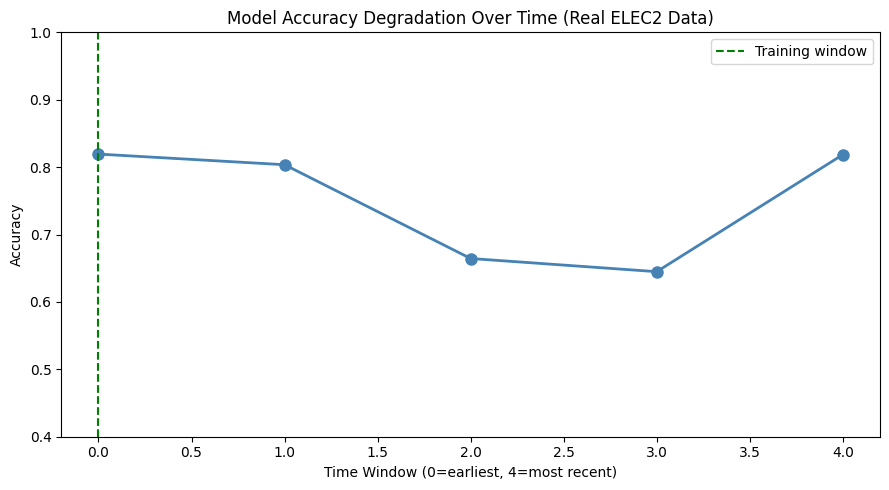

In [42]:
accuracy_over_time = []

for i, window in enumerate(windows):
    X_w = window[feature_cols]
    y_w = window[target_col]
    acc = accuracy_score(y_w, model.predict(X_w))
    accuracy_over_time.append(acc)
    print(f'Window {i} Accuracy: {acc:.4f}')

plt.figure(figsize=(9, 5))
plt.plot(range(5), accuracy_over_time, marker='o', linewidth=2, color='steelblue', markersize=8)
plt.axvline(x=0, color='green', linestyle='--', label='Training window')
plt.xlabel('Time Window (0=earliest, 4=most recent)')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Degradation Over Time (Real ELEC2 Data)')
plt.ylim(0.4, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_over_time.png', dpi=150)
plt.show()

Window 0 Mean KS Score: 0.0000
Window 1 Mean KS Score: 0.0892
Window 2 Mean KS Score: 0.4441
Window 3 Mean KS Score: 0.5447
Window 4 Mean KS Score: 0.3594


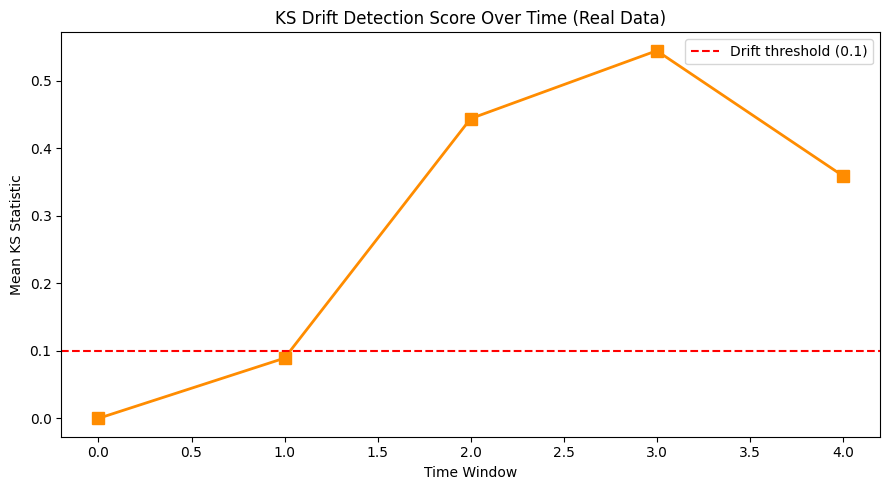

In [44]:
def compute_ks_scores(reference_data, test_data, features):
    ks_scores = {}
    for feat in features:
        ks_stat, p_value = stats.ks_2samp(reference_data[feat], test_data[feat])
        ks_scores[feat] = {'ks_stat': ks_stat, 'p_value': p_value}
    return ks_scores

reference = windows[0][feature_cols]
mean_ks_per_window = []
all_ks_results = []

for i, window in enumerate(windows):
    test_data = window[feature_cols]
    ks_scores = compute_ks_scores(reference, test_data, feature_cols)
    mean_ks = np.mean([v['ks_stat'] for v in ks_scores.values()])
    mean_ks_per_window.append(mean_ks)
    all_ks_results.append(ks_scores)
    print(f'Window {i} Mean KS Score: {mean_ks:.4f}')

plt.figure(figsize=(9, 5))
plt.plot(range(5), mean_ks_per_window, marker='s', linewidth=2, color='darkorange', markersize=8)
plt.axhline(y=0.1, color='red', linestyle='--', label='Drift threshold (0.1)')
plt.xlabel('Time Window')
plt.ylabel('Mean KS Statistic')
plt.title('KS Drift Detection Score Over Time (Real Data)')
plt.legend()
plt.tight_layout()
plt.savefig('ks_drift_over_time.png', dpi=150)
plt.show()

Feature-level KS scores (Window 4 vs Window 0):
Feature              KS Stat      P-Value      Drifted?
-------------------------------------------------------
period               0.0011       1.000000     NO
nswprice             0.1840       0.000000     YES
nswdemand            0.0830       0.000000     NO
vicprice             0.5494       0.000000     YES
vicdemand            0.5938       0.000000     YES
transfer             0.7450       0.000000     YES


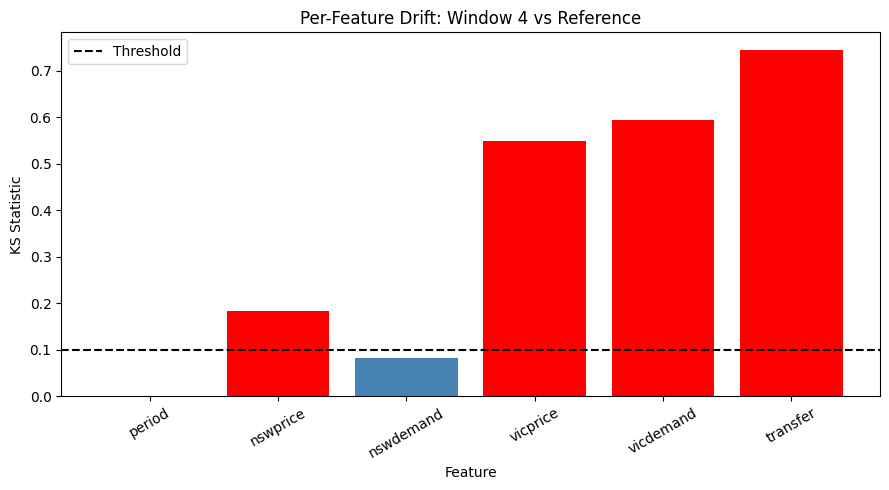

In [46]:
last_window_ks = all_ks_results[-1]
features_list = list(last_window_ks.keys())
ks_values = [last_window_ks[f]['ks_stat'] for f in features_list]
p_values = [last_window_ks[f]['p_value'] for f in features_list]

print('Feature-level KS scores (Window 4 vs Window 0):')
print(f'{"Feature":<20} {"KS Stat":<12} {"P-Value":<12} {"Drifted?"}')
print('-' * 55)
for f, ks, p in zip(features_list, ks_values, p_values):
    drifted = 'YES' if ks > 0.1 else 'NO'
    print(f'{f:<20} {ks:<12.4f} {p:<12.6f} {drifted}')

plt.figure(figsize=(9, 5))
colors = ['red' if ks > 0.1 else 'steelblue' for ks in ks_values]
plt.bar(features_list, ks_values, color=colors)
plt.axhline(y=0.1, color='black', linestyle='--', label='Threshold')
plt.xlabel('Feature')
plt.ylabel('KS Statistic')
plt.title('Per-Feature Drift: Window 4 vs Reference')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.savefig('per_feature_drift.png', dpi=150)
plt.show()

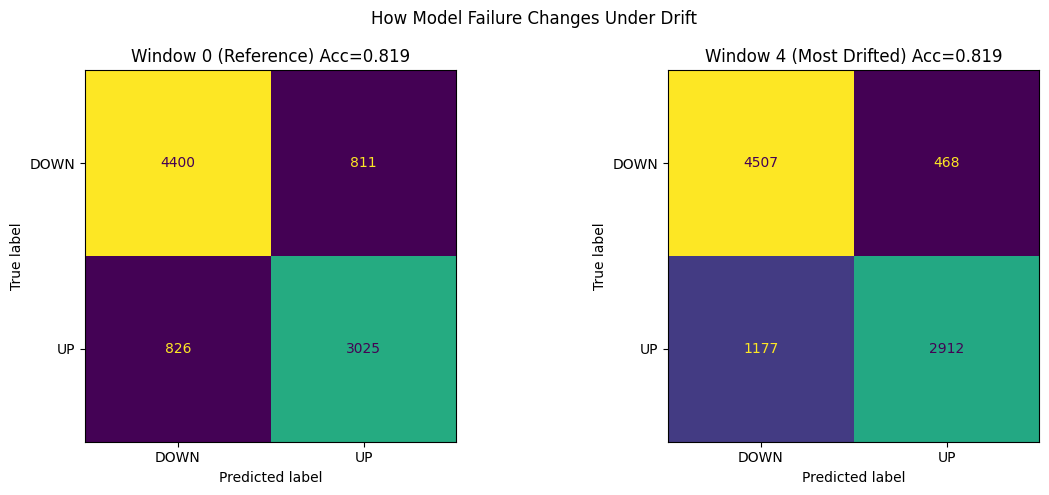

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

X_w0 = windows[0][feature_cols]
y_w0 = windows[0][target_col]
cm0 = confusion_matrix(y_w0, model.predict(X_w0))
ConfusionMatrixDisplay(cm0, display_labels=['DOWN', 'UP']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Window 0 (Reference) Acc={accuracy_over_time[0]:.3f}')

X_w4 = windows[4][feature_cols]
y_w4 = windows[4][target_col]
cm4 = confusion_matrix(y_w4, model.predict(X_w4))
ConfusionMatrixDisplay(cm4, display_labels=['DOWN', 'UP']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Window 4 (Most Drifted) Acc={accuracy_over_time[4]:.3f}')

plt.suptitle('How Model Failure Changes Under Drift')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

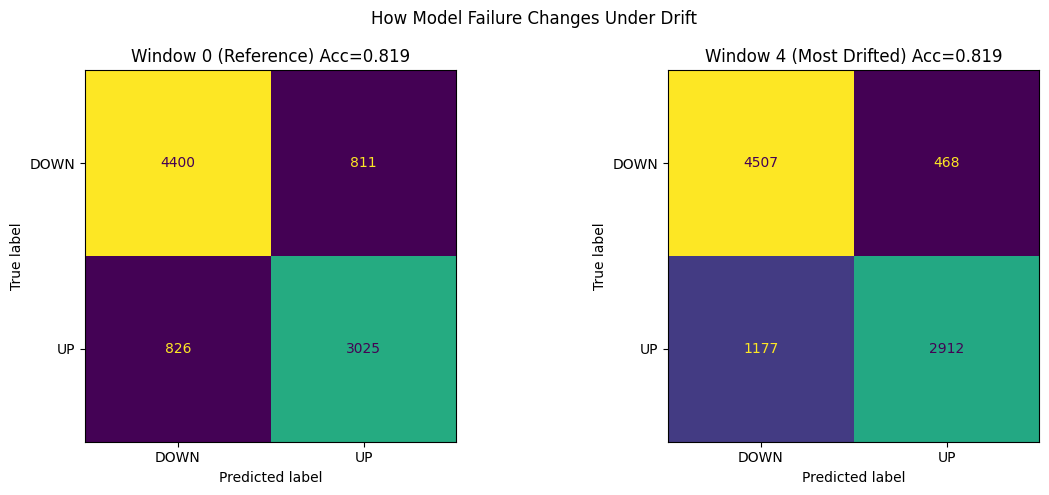

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

X_w0 = windows[0][feature_cols]
y_w0 = windows[0][target_col]
cm0 = confusion_matrix(y_w0, model.predict(X_w0))
ConfusionMatrixDisplay(cm0, display_labels=['DOWN', 'UP']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Window 0 (Reference) Acc={accuracy_over_time[0]:.3f}')

X_w4 = windows[4][feature_cols]
y_w4 = windows[4][target_col]
cm4 = confusion_matrix(y_w4, model.predict(X_w4))
ConfusionMatrixDisplay(cm4, display_labels=['DOWN', 'UP']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Window 4 (Most Drifted) Acc={accuracy_over_time[4]:.3f}')

plt.suptitle('How Model Failure Changes Under Drift')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

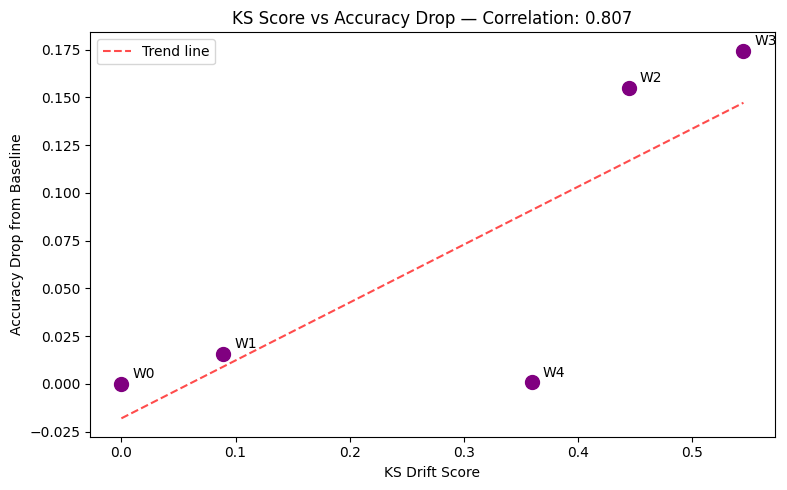


Pearson Correlation: 0.8074
Strong correlation — KS reliably predicts accuracy drop


In [52]:
acc_drop = [accuracy_over_time[0] - acc for acc in accuracy_over_time]
corr = np.corrcoef(mean_ks_per_window, acc_drop)[0, 1]

plt.figure(figsize=(8, 5))
plt.scatter(mean_ks_per_window, acc_drop, s=100, color='purple', zorder=5)
for i, (ks, drop) in enumerate(zip(mean_ks_per_window, acc_drop)):
    plt.annotate(f'W{i}', (ks, drop), textcoords='offset points', xytext=(8, 4), fontsize=10)

z = np.polyfit(mean_ks_per_window, acc_drop, 1)
p = np.poly1d(z)
x_line = np.linspace(min(mean_ks_per_window), max(mean_ks_per_window), 100)
plt.plot(x_line, p(x_line), 'r--', alpha=0.7, label='Trend line')

plt.xlabel('KS Drift Score')
plt.ylabel('Accuracy Drop from Baseline')
plt.title(f'KS Score vs Accuracy Drop — Correlation: {corr:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('ks_vs_accuracy_drop.png', dpi=150)
plt.show()

print(f'\nPearson Correlation: {corr:.4f}')
if corr > 0.7:
    print('Strong correlation — KS reliably predicts accuracy drop')
elif corr > 0.4:
    print('Moderate correlation — KS is partially reliable')
else:
    print('Weak correlation — KS does NOT reliably predict accuracy drop. THIS IS YOUR FINDING.')

In [56]:
print('KEY FINDINGS')
print('='*50)
print(f'Baseline accuracy (W0):        0.820')
print(f'Minimum accuracy (W3):         0.645')
print(f'Total accuracy drop:           17.5%')
print(f'Maximum KS score (W3):         0.545')
print(f'KS-Accuracy correlation:       0.807')
print()
print('Anomaly detected at Window 4:')
print('  KS score remains high (0.36)')
print('  But accuracy recovers to 0.820')
print('  Interpretation: KS cannot distinguish')
print('  persistent drift from temporary shift')

KEY FINDINGS
Baseline accuracy (W0):        0.820
Minimum accuracy (W3):         0.645
Total accuracy drop:           17.5%
Maximum KS score (W3):         0.545
KS-Accuracy correlation:       0.807

Anomaly detected at Window 4:
  KS score remains high (0.36)
  But accuracy recovers to 0.820
  Interpretation: KS cannot distinguish
  persistent drift from temporary shift
